In [2]:
import pandas as pd

df = pd.read_csv("metadata_full.csv")
originals = df[df["aug_type"] == "original"].copy()
print(f"Loaded {len(originals)} original recordings")

Loaded 165 original recordings


In [3]:
import numpy as np, librosa, time

def extract_features(path, sr=22050, duration=60):
    """Aggregated timbral + tonal features from one recording."""
    y, sr = librosa.load(path, sr=sr, duration=duration)
    feats = {}

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)      # timbre
    for i in range(mfcc.shape[0]):
        feats[f"mfcc{i+1}_mean"] = mfcc[i].mean()
        feats[f"mfcc{i+1}_std"]  = mfcc[i].std()

    chroma = librosa.feature.chroma_stft(y=y, sr=sr)         # tonal / pitch-class (key for raga)
    for i in range(chroma.shape[0]):
        feats[f"chroma{i+1}_mean"] = chroma[i].mean()
        feats[f"chroma{i+1}_std"]  = chroma[i].std()

    feats["spec_centroid_mean"]  = float(librosa.feature.spectral_centroid(y=y, sr=sr).mean())
    feats["spec_bandwidth_mean"] = float(librosa.feature.spectral_bandwidth(y=y, sr=sr).mean())
    feats["spec_rolloff_mean"]   = float(librosa.feature.spectral_rolloff(y=y, sr=sr).mean())
    feats["zcr_mean"]            = float(librosa.feature.zero_crossing_rate(y).mean())
    feats["rms_mean"]            = float(librosa.feature.rms(y=y).mean())
    return feats

# Extract for all 165 originals (this is the slow step — a couple of minutes)
rows, start = [], time.time()
for idx, (_, row) in enumerate(originals.iterrows(), 1):
    f = extract_features(row["full_path"])
    f.update({"filename": row["filename"], "raga": row["raga"]})
    rows.append(f)
    if idx % 20 == 0:
        print(f"  {idx}/{len(originals)} done ({time.time()-start:.0f}s)")

features_df = pd.DataFrame(rows)
features_df.to_csv("features_originals.csv", index=False)
print(f"\nFeature matrix shape: {features_df.shape}")
features_df.head()

  20/165 done (50s)
  40/165 done (53s)
  60/165 done (57s)
  80/165 done (60s)
  100/165 done (63s)
  120/165 done (66s)
  140/165 done (69s)
  160/165 done (71s)

Feature matrix shape: (165, 71)


,mfcc1_mean,mfcc1_std,mfcc2_mean,mfcc2_std,mfcc3_mean,mfcc3_std,mfcc4_mean,mfcc4_std,mfcc5_mean,mfcc5_std,...,chroma11_std,chroma12_mean,chroma12_std,spec_centroid_mean,spec_bandwidth_mean,spec_rolloff_mean,zcr_mean,rms_mean,filename,raga
0,-341.055420,57.652348,58.008747,27.808699,-20.423800,14.391862,2.841578,8.599311,-4.173000,9.856713,...,0.217641,0.446924,0.476497,2168.005618,2267.087243,4064.117304,0.083504,0.046427,Hamsadhwani_happy_09.wav,hamsadhwani
1,-297.466553,61.179760,48.761520,29.516438,-35.799633,19.553106,1.402969,7.335602,-3.995960,11.388418,...,0.323369,0.172154,0.314798,2176.155085,2122.028023,3878.112396,0.095648,0.075340,Bhairavi_devotion_14.wav,bhairavi
2,-218.586411,110.661583,59.923347,47.318810,-19.736134,25.651041,-0.641765,12.689868,-7.073724,16.077208,...,0.272575,0.326090,0.358224,2603.064327,2410.770920,5097.473739,0.117309,0.091574,Poorvikalyani_12.wav,poorvikalyani
3,-273.829437,65.589302,94.425575,21.178089,-13.169884,13.960237,7.893772,10.676681,9.710755,12.058299,...,0.179006,0.154250,0.261802,2144.284162,2498.295673,4398.281641,0.075401,0.038260,Poorvikalyani_06.wav,poorvikalyani
4,-215.594406,91.643898,54.153164,34.720654,-27.103008,20.961109,0.996838,12.302412,-6.556793,13.587076,...,0.269711,0.214995,0.282753,2585.078193,2363.521830,4995.753086,0.132093,0.082382,Thodi_09.wav,thodi


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

# Load features, restrict to the TRAINING originals (test stays sealed)
features    = pd.read_csv("features_originals.csv")
train_files = pd.read_csv("train_originals.csv")["filename"]

train = features[features["filename"].isin(train_files)].copy()
X = train.drop(columns=["filename", "raga"])
y = train["raga"]
print(f"Training set: {X.shape[0]} samples, {X.shape[1]} features, {y.nunique()} classes\n")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Dummy (chance)":       DummyClassifier(strategy="most_frequent"),
    "Logistic Regression":  Pipeline([("scale", StandardScaler()),
                                       ("clf", LogisticRegression(max_iter=2000))]),
    "Random Forest":        RandomForestClassifier(n_estimators=300, random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
    res = cross_validate(model, X, y, cv=cv, scoring=["accuracy", "f1_macro"])
    a, f = res["test_accuracy"], res["test_f1_macro"]
    print(f"{name:22s}  acc = {a.mean():.3f} ± {a.std():.3f}   "
          f"macro-F1 = {f.mean():.3f} ± {f.std():.3f}")

Training set: 132 samples, 69 features, 11 classes

Dummy (chance)          acc = 0.076 ± 0.001   macro-F1 = 0.013 ± 0.000
Logistic Regression     acc = 0.871 ± 0.090   macro-F1 = 0.868 ± 0.099
Random Forest           acc = 0.803 ± 0.096   macro-F1 = 0.802 ± 0.085
HistGradientBoosting    acc = 0.780 ± 0.075   macro-F1 = 0.787 ± 0.081


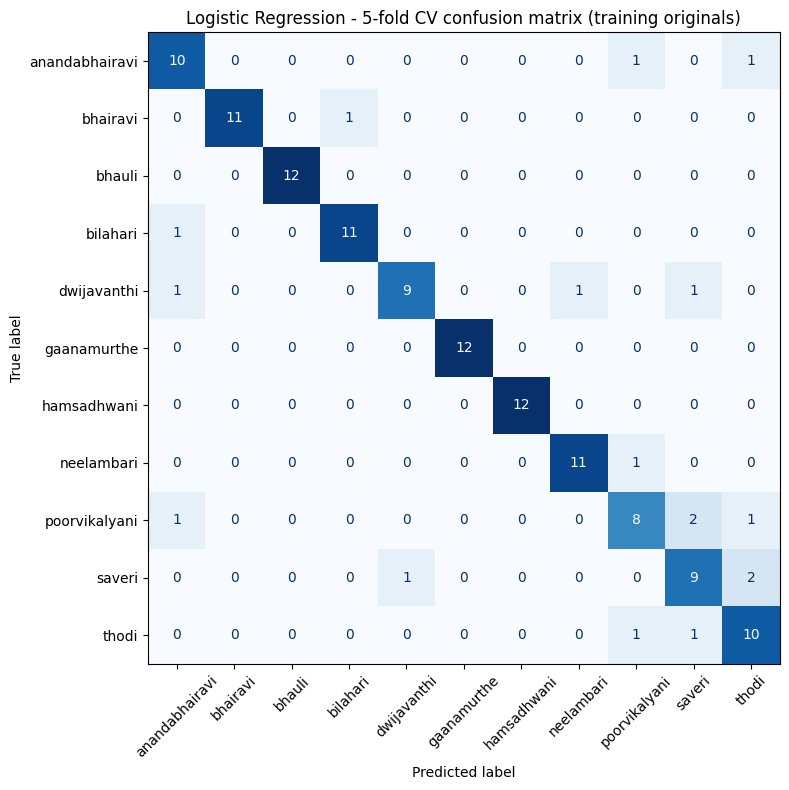

                precision    recall  f1-score   support

anandabhairavi       0.77      0.83      0.80        12
      bhairavi       1.00      0.92      0.96        12
        bhauli       1.00      1.00      1.00        12
      bilahari       0.92      0.92      0.92        12
   dwijavanthi       0.90      0.75      0.82        12
   gaanamurthe       1.00      1.00      1.00        12
   hamsadhwani       1.00      1.00      1.00        12
    neelambari       0.92      0.92      0.92        12
 poorvikalyani       0.73      0.67      0.70        12
        saveri       0.69      0.75      0.72        12
         thodi       0.71      0.83      0.77        12

      accuracy                           0.87       132
     macro avg       0.88      0.87      0.87       132
  weighted avg       0.88      0.87      0.87       132



In [5]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

best_model = Pipeline([("scale", StandardScaler()),
                       ("clf", LogisticRegression(max_iter=2000))])

# Out-of-fold predictions across the 5 folds
y_pred = cross_val_predict(best_model, X, y, cv=cv)

labels = sorted(y.unique())
cm = confusion_matrix(y, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels= labels).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
ax.set_title("Logistic Regression - 5-fold CV confusion matrix (training originals)")
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

print(classification_report(y, y_pred, labels=labels))

In [6]:
from sklearn.metrics import accuracy_score

test_files = pd.read_csv("test_originals.csv")["filename"]
test = features[features["filename"].isin(test_files)].copy()

X_test = test.drop(columns=["filename", "raga"])
y_test = test["raga"]

best_model.fit(X, y)
test_pred = best_model.predict(X_test)

print(f"Held-out test accuracy: {accuracy_score(y_test, test_pred):.3f}\n")
print(classification_report(y_test, test_pred, labels=labels))

Held-out test accuracy: 0.909

                precision    recall  f1-score   support

anandabhairavi       0.75      1.00      0.86         3
      bhairavi       1.00      0.67      0.80         3
        bhauli       1.00      1.00      1.00         3
      bilahari       0.75      1.00      0.86         3
   dwijavanthi       1.00      0.67      0.80         3
   gaanamurthe       1.00      1.00      1.00         3
   hamsadhwani       1.00      1.00      1.00         3
    neelambari       1.00      1.00      1.00         3
 poorvikalyani       1.00      1.00      1.00         3
        saveri       1.00      0.67      0.80         3
         thodi       0.75      1.00      0.86         3

      accuracy                           0.91        33
     macro avg       0.93      0.91      0.91        33
  weighted avg       0.93      0.91      0.91        33

